<a href="https://colab.research.google.com/github/Bamboohoccode/LLMs_From_Scratch/blob/main/Chapter_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 6.1 Different categories of finetuning

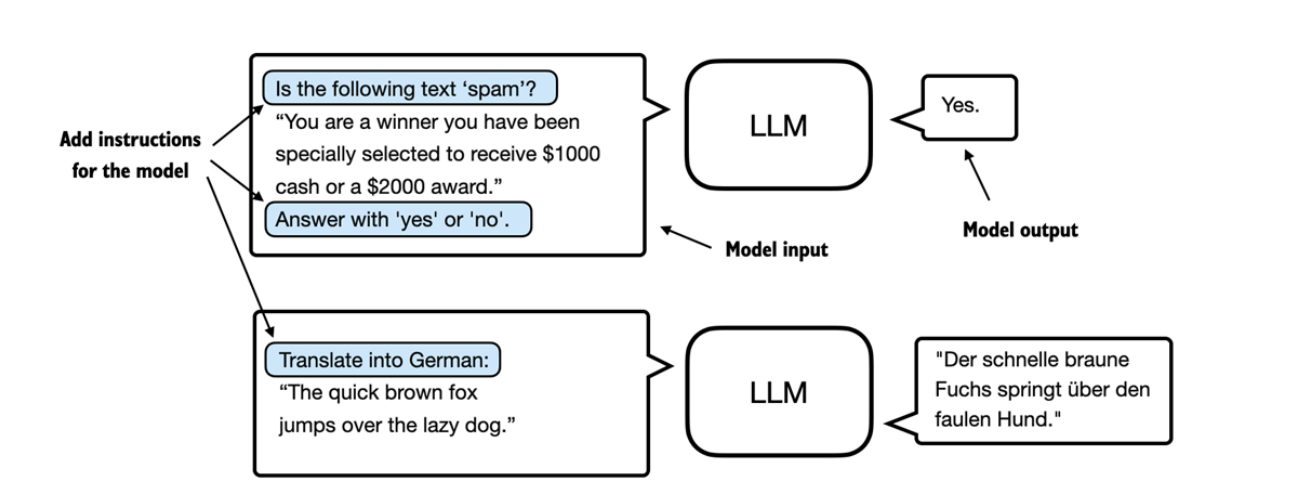

Illustration of two different instruction-finetuning scenarios. At the top, the model is tasked with
determining whether a given text is spam. At the bottom, the model is given an instruction on how to translate
an English sentence into German.

# 6.2 Preparing the dataset

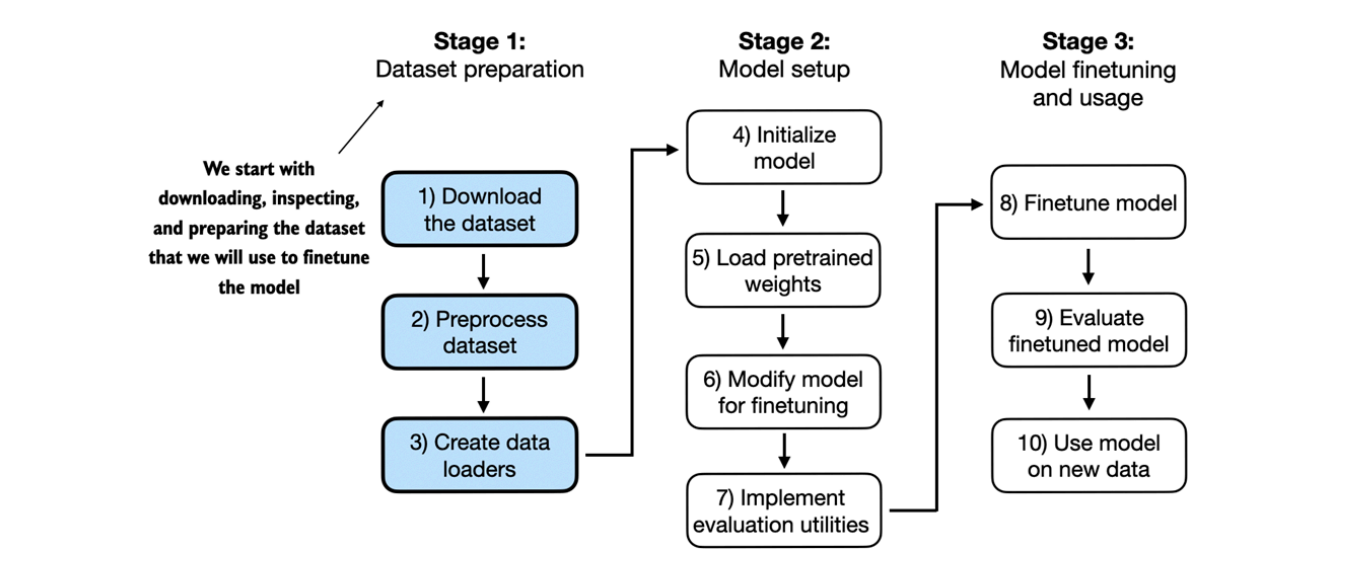

In [ ]:
if __name__ == "__main__":
    import urllib.request
    import zipfile
    import os
    from pathlib import Path
    url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"
    zip_path = "sms_spam_collection.zip"
    extracted_path = "sms_spam_collection"
    data_file_path = Path(extracted_path) / "SMSSpamCollection.tsv"
    def download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path):
        if data_file_path.exists():
            print(f"{data_file_path} already exists. Skipping download and extraction.")
            return
        with urllib.request.urlopen(url) as response: #A
            with open(zip_path, "wb") as out_file:
                out_file.write(response.read())
        with zipfile.ZipFile(zip_path, "r") as zip_ref: #B
            zip_ref.extractall(extracted_path)
        original_file_path = Path(extracted_path) / "SMSSpamCollection"
        os.rename(original_file_path, data_file_path) #C
        print(f"File downloaded and saved as {data_file_path}")
    download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path)


sms_spam_collection/SMSSpamCollection.tsv already exists. Skipping download and extraction.


In [ ]:
if __name__ == "__main__":

    import pandas as pd
    import numpy as np
    data_path = "/content/sms_spam_collection/SMSSpamCollection.tsv"
    df = pd.read_csv(data_path,sep = "\t",header = None,names = ["Label","Text"])

We have 747 spam message

In [ ]:
if __name__ == "__main__":
    print(df["Label"].value_counts())

Label
ham     4825
spam     747
Name: count, dtype: int64


Because of educational purpose and saving time,we undersample the data with 747 samples each categories

In [ ]:

def create_balanced_df(df):
    num_spam = df[df["Label"] == "spam"].shape[0]
    ham_subset = df.sample(num_spam,random_state=123)
    new_df = pd.concat([df[df["Label"] == "spam"],ham_subset],axis = 0)
    return new_df


In [ ]:
if __name__ == "__main__":
    balanced_df = create_balanced_df(df)
    balanced_df

Next, we convert the "string" class labels "ham" and "spam" into integer class labels 0 and
1, respectively:

In [ ]:
if __name__ == "__main__":
    balanced_df["Label"] = balanced_df["Label"].map({"ham" : 0,"spam" : 1})

In [ ]:
if __name__ == "__main__":
    balanced_df.head()

We create a random_split function to split the dataset into three parts: 70% for
training, 10% for validation, and 20% for testing. (These ratios are common in machine
learning to train, adjust, and evaluate models.)

In [ ]:
def random_split(df, train_frac, validation_frac):
    df = df.sample(frac=1, random_state=123).reset_index(drop=True)
    train_end = int(len(df) * train_frac)
    validation_end = train_end + int(len(df) * validation_frac)
    train_df = df[:train_end]
    validation_df = df[train_end:validation_end]
    test_df = df[validation_end:]
    return train_df, validation_df, test_df
train_df, validation_df, test_df = random_split(balanced_df, 0.7, 0.1)

In [ ]:
if __name__ == "__main__":
    train_df

# 6.3 Creating data loaders

- In this section, we develop PyTorch data loaders that are conceptually similar to the ones
we implemented in chapter 2.
- Previously, in chapter 2, we utilized a sliding window technique to generate uniformly
sized text chunks, which were then grouped into batches for more efficient model training.Each chunk functioned as an individual training instance.
- However, in this chapter, we are working with a spam dataset that contains text
messages of varying lengths. To batch these messages as we did with the text chunks in
chapter 2, we have two primary options:
1. Truncate all messages to the length of the shortest message in the
dataset or batch.
2. Pad all messages to the length of the longest message in the dataset or
batch

In [ ]:
if __name__ == "__main__":
    import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")
print(tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"}))

[50256]


In [ ]:
if __name__ == "__main__":
    train_df.to_csv("train.csv", index=None)
    validation_df.to_csv("validation.csv", index=None)
    test_df.to_csv("test.csv", index=None)

This SpamDataset class handles several key tasks: it identifies the longest sequence in the training dataset, encodes the text messages, and ensures that all
other sequences are padded with a padding token to match the length of the longest
sequence.

#### What did DataSet and DataLoader do ?

In [ ]:
import torch
from torch.utils.data import Dataset

class SpamDataset(Dataset):
    def __init__(self,csv_file,tokenizer,max_length = None,pad_token_id = 50256):
        self.data = pd.read_csv(csv_file)
        self.encoded_texts =[tokenizer.encode(encoded) for encoded in self.data["Text"]]
        if max_length is None:
            self.max_length = self._longest_encoded_length()
        else:
            self.max_length = max_length
            self.encoded_texts = [text[:max_length] for text in self.encoded_texts]

        self.encoded_texts = [text + [pad_token_id] * (self.max_length - len(text)) for text in self.encoded_texts]

    def __getitem__(self, index):
            encoded = self.encoded_texts[index]
            label = self.data.iloc[index]["Label"]
            return (
            torch.tensor(encoded, dtype=torch.long),
            torch.tensor(label, dtype=torch.long)
            )

    def __len__(self):
        return len(self.data)
    def _longest_encoded_length(self):
        max_length = 0
        for encoded_text in self.encoded_texts:
            encoded_length = len(encoded_text)
            if encoded_length > max_length:
                max_length = encoded_length
        return max_length

In [ ]:
if __name__ == "__main__":
    train_dataset = SpamDataset(csv_file= "/content/train.csv",
                            max_length = 120,
                            tokenizer = tokenizer)

In [ ]:
if __name__ == "__main__":
    val_dataset = SpamDataset(csv_file="/content/validation.csv",
                            max_length = 120,
                            tokenizer = tokenizer)
    test_dataset = SpamDataset(csv_file="/content/test.csv",
                            max_length = 120,
                          tokenizer = tokenizer)




###We should use 1024 for max_length becuz that's the maxium of the tokenizer,but in this Chapter I'll use 120 for the similarity.





## EXERCISE 6.1 INCREASING THE CONTEXT LENGTH
Pad the inputs to the maximum number of tokens the model supports and observe
how it impacts the predictive performance

 ### I'll be right back and do this exercise

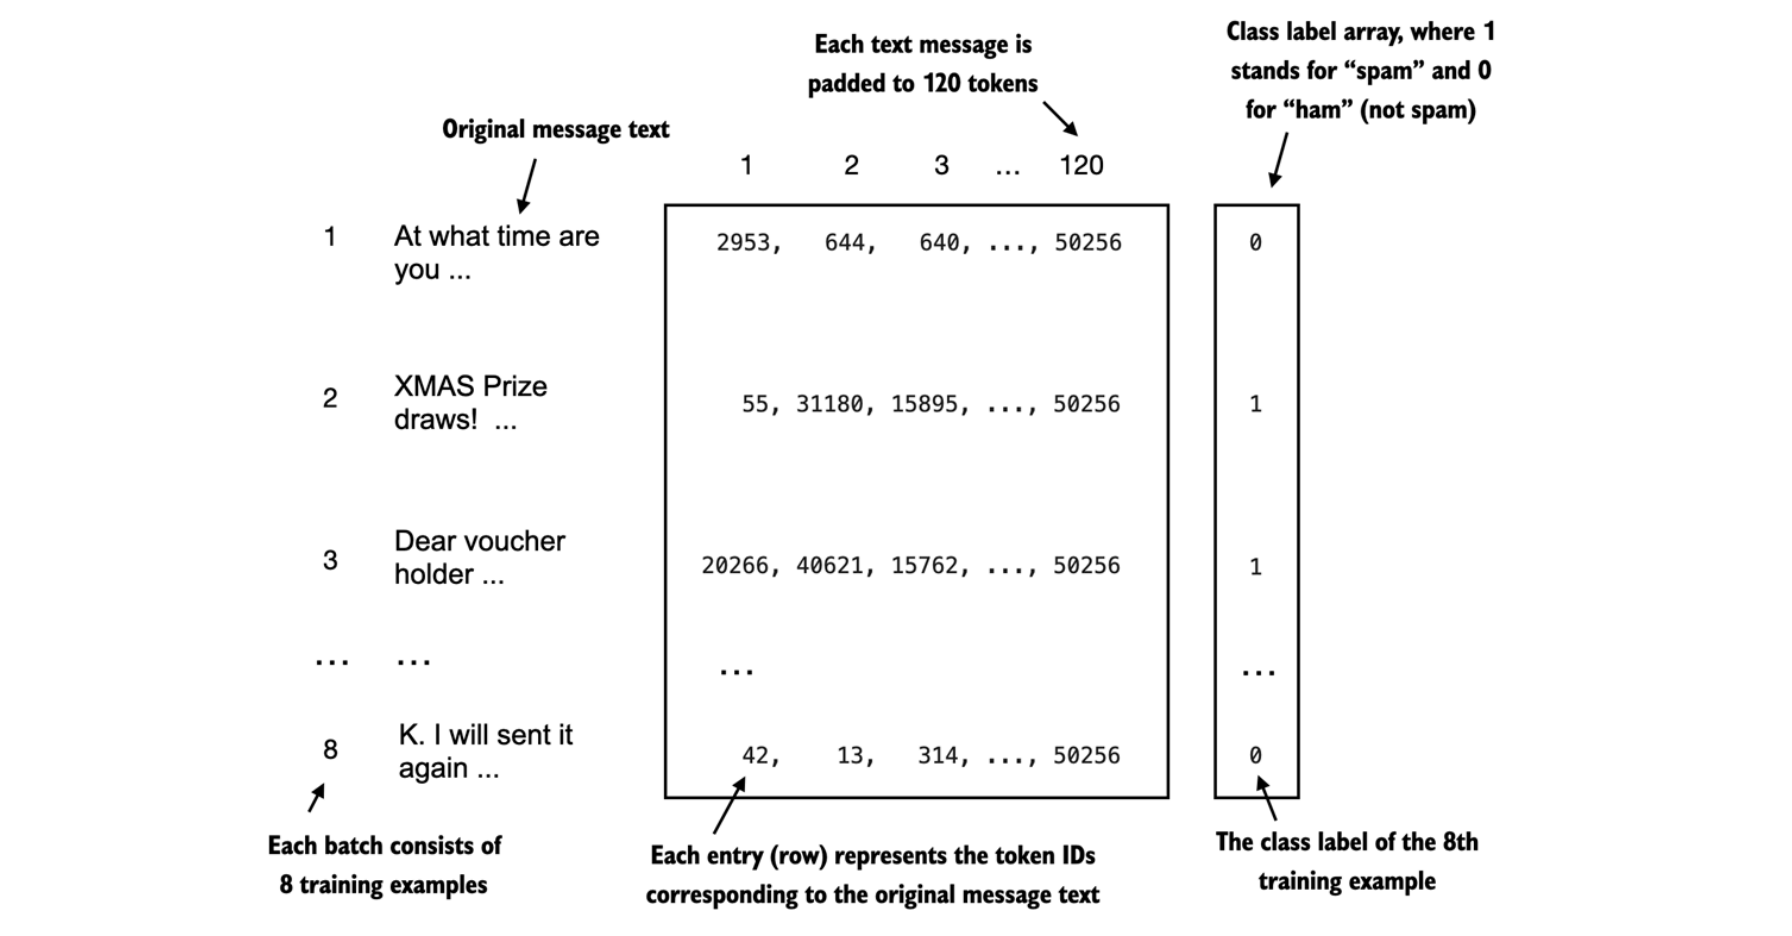

 choosing a batch size of 8, each batch will consist of 8
training examples of length 120 and the corresponding class label of each example


#### Mini Question: Why and When we must to customize the DataLoader and when not ?

In [ ]:
if __name__ == "__main__":
    from torch.utils.data import DataLoader
    num_workers = 0 #A
    batch_size = 8
    train_loader = DataLoader(train_dataset,
                            batch_size = 8,
                            shuffle = True,
                                num_workers=num_workers,
                            drop_last = True)

    val_loader = DataLoader(dataset=val_dataset,
                            batch_size=batch_size,
                            num_workers=num_workers,
                            drop_last=False)

    test_loader = DataLoader(dataset=test_dataset,
                            batch_size=batch_size,
                            num_workers=num_workers,
                            drop_last=False,)

In [ ]:
for input_b,output_b in train_loader:
    pass
print(input_b.shape,output_b.shape)

torch.Size([8, 120]) torch.Size([8])


# 6.4 Initializing a model with pretrained weights


In [ ]:
!pip install importnb
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


tensor([[0.2260, 0.3470, 0.0000, 0.2216, 0.0000, 0.0000],
        [0.2133, 0.2394, 0.0000, 0.5198, 0.3297, 0.0000]],
       grad_fn=<ReluBackward0>)


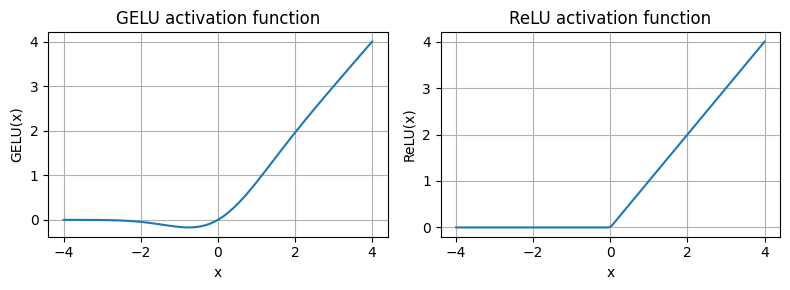

layers.0.0.weight has gradient mean of 0.017917921766638756
layers.1.0.weight has gradient mean of 0.02229098230600357
layers.2.0.weight has gradient mean of 0.011262618936598301
layers.3.0.weight has gradient mean of 0.03297118842601776
layers.4.0.weight has gradient mean of 0.025448843836784363
output.weight has gradient mean of 0.14177106320858002
layers.0.0.weight has gradient mean of 7.291763267858187e-06
layers.1.0.weight has gradient mean of 3.3261159842368215e-05
layers.2.0.weight has gradient mean of 7.325314800255e-05
layers.3.0.weight has gradient mean of 0.0006181434728205204
layers.4.0.weight has gradient mean of 0.00227734143845737
output.weight has gradient mean of 0.011895890347659588
Input shape: torch.Size([2, 4, 768])
Output shape: torch.Size([2, 4, 768])
Input batch:
 tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])

Output shape: torch.Size([2, 4, 50257])
tensor([[[-0.3556, -0.2533, -0.3395,  ...,  0.0093, -0.6117,  0.0429],
         [-0.1311, -

In [ ]:
 import sys
sys.path.append('/content/drive/MyDrive/Colab Notebooks/')

from importnb import Notebook
with Notebook():
    from Chapter_4 import GPTModel

We should import from chapter_5 but there're some bugs

In [ ]:
def assign(left, right):
    if left.shape != right.shape:
        raise ValueError(f"Shape mismatch. Left: {left.shape}, Right: {right.shape}")
    return torch.nn.Parameter(torch.tensor(right))
def load_weights_into_gpt(gpt, params):
    gpt.pos_embedded.weight = assign(gpt.pos_embedded.weight, params['wpe']) #A
    gpt.tok_embedded.weight = assign(gpt.tok_embedded.weight, params['wte'])
    for b in range(len(params["blocks"])): #B
        q_w, k_w, v_w = np.split( #C
        (params["blocks"][b]["attn"]["c_attn"])["w"], 3, axis=-1)

        gpt.transformer[b].att.W_q.weight = assign(
        gpt.transformer[b].att.W_q.weight, q_w.T)
        gpt.transformer[b].att.W_k.weight = assign(
        gpt.transformer[b].att.W_k.weight, k_w.T)
        gpt.transformer[b].att.W_v.weight = assign(
        gpt.transformer[b].att.W_v.weight, v_w.T)

        q_b, k_b, v_b = np.split(
        (params["blocks"][b]["attn"]["c_attn"])["b"], 3, axis=-1)

        gpt.transformer[b].att.W_q.bias = assign(
        gpt.transformer[b].att.W_q.bias, q_b)
        gpt.transformer[b].att.W_k.bias = assign(
        gpt.transformer[b].att.W_k.bias, k_b)
        gpt.transformer[b].att.W_v.bias = assign(
        gpt.transformer[b].att.W_v.bias, v_b)
        gpt.transformer[b].att.out_proj.weight = assign(
        gpt.transformer[b].att.out_proj.weight,
        params["blocks"][b]["attn"]["c_proj"]["w"].T)
        gpt.transformer[b].att.out_proj.bias = assign(
        gpt.transformer[b].att.out_proj.bias,
        params["blocks"][b]["attn"]["c_proj"]["b"])
        gpt.transformer[b].ff.layers[0].weight = assign(
        gpt.transformer[b].ff.layers[0].weight,
        params["blocks"][b]["mlp"]["c_fc"]["w"].T)
        gpt.transformer[b].ff.layers[0].bias = assign(
        gpt.transformer[b].ff.layers[0].bias,
        params["blocks"][b]["mlp"]["c_fc"]["b"])
        gpt.transformer[b].ff.layers[2].weight = assign(
        gpt.transformer[b].ff.layers[2].weight,
        params["blocks"][b]["mlp"]["c_proj"]["w"].T)
        gpt.transformer[b].ff.layers[2].bias = assign(
        gpt.transformer[b].ff.layers[2].bias,
        params["blocks"][b]["mlp"]["c_proj"]["b"])
        gpt.transformer[b].LayerNorm1.gamma = assign(
        gpt.transformer[b].LayerNorm1.gamma,
        params["blocks"][b]["ln_1"]["g"])
        gpt.transformer[b].LayerNorm1.beta = assign(
        gpt.transformer[b].LayerNorm1.beta,
        params["blocks"][b]["ln_1"]["b"])
        gpt.transformer[b].LayerNorm2.gamma = assign(
        gpt.transformer[b].LayerNorm2.gamma,
        params["blocks"][b]["ln_2"]["g"])
        gpt.transformer[b].LayerNorm2.beta = assign(
        gpt.transformer[b].LayerNorm2.beta,
        params["blocks"][b]["ln_2"]["b"])
    gpt.layernorm.scale = assign(gpt.layernorm.gamma, params["g"])
    gpt.layernorm.shift = assign(gpt.layernorm.beta, params["b"])
    gpt.output.weight = assign(gpt.output.weight, params["wte"]) #D

In [ ]:
if __name__ == "__main__":
    CHOOSE_MODEL = "gpt2-small (124M)"
    INPUT_PROMPT = "Every effort moves"
    BASE_CONFIG = {
    "vocab_size": 50257,# Vocabulary size
    "context_length": 1024,# Context length
    "drop_rate": 0.0,# Dropout rate
    "qkv_bias": True# Query-key-value bias
    }
    model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
    }

    BASE_CONFIG.update(model_configs[CHOOSE_MODEL])
    assert train_dataset.max_length <= BASE_CONFIG["context_length"], (
        f"Dataset length {train_dataset.max_length} exceeds model's context "
        f"length {BASE_CONFIG['context_length']}. Reinitialize data sets with "
        f"`max_length={BASE_CONFIG['context_length']}`"
        )

assert điều_kiện, "Thông báo lỗi (tùy chọn)"


In [ ]:
if __name__ == "__main__":
    from gpt_download import download_and_load_gpt2
    model_size = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")
    settings, params = download_and_load_gpt2(model_size=model_size, models_dir="gpt2")
    model = GPTModel(BASE_CONFIG)
    load_weights_into_gpt(model,params)
    model.eval()

File already exists and is up-to-date: gpt2/124M/checkpoint
File already exists and is up-to-date: gpt2/124M/encoder.json
File already exists and is up-to-date: gpt2/124M/hparams.json
File already exists and is up-to-date: gpt2/124M/model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2/124M/model.ckpt.index
File already exists and is up-to-date: gpt2/124M/model.ckpt.meta
File already exists and is up-to-date: gpt2/124M/vocab.bpe


### Import function :vv

In [ ]:
def text_to_token_ids(text,tokenizer):
    encoder = tokenizer.encode(text,allowed_special ={'<|endoftext|>'})
    tensor = torch.tensor(encoder).unsqueeze(0) # Corrected line
    return tensor
def token_to_text(text,tokenizer):
    flat = text.squeeze(0)
    return tokenizer.decode(flat.tolist())
with Notebook():
    from Chapter_4 import generate_text_simple

In [ ]:
import tiktoken
if __name__ == "__main__":
    tokenizer = tiktoken.get_encoding("gpt2")
    text_1 = "Every effort move you"
    tokens_res = generate_text_simple(model,text_to_token_ids(text_1,tokenizer),max_new_tokens= 50,context_size = 5)
    print("Predicted Sentences: ",token_to_text(tokens_res,tokenizer))

Predicted Sentences:  Every effort move you, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the


In [ ]:
if __name__ == "__main__":
    text_2 = (
    "Is the following text 'spam'? Answer with 'yes' or 'no':"
    " 'You are a winner you have been specially"
    " selected to receive $1000 cash or a $2000 award.'"
    )
    tokens_res_2 = generate_text_simple(model,text_to_token_ids(text_2,tokenizer),max_new_tokens= 50,context_size = 5)
    print("Predicted Sentences: ", token_to_text(tokens_res_2,tokenizer))

Predicted Sentences:  Is the following text 'spam'? Answer with 'yes' or 'no': 'You are a winner you have been specially selected to receive $1000 cash or a $2000 award.', the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the


# 6.5 Adding a classification head

## This new model.out_head output layer has its requires_grad attribute set to True by default, which means that it's the only layer in the model that will be updated during training.

In [ ]:
import torch
import torch.nn as nn
if __name__ == "__main__":
    model.output = nn.Linear(BASE_CONFIG["emb_dim"],2) # Num classes is 2

Additionally, we configure the last transformer block and the final LayerNorm module,
which connects this block to the output layer, to be trainable, as depicted in this picture

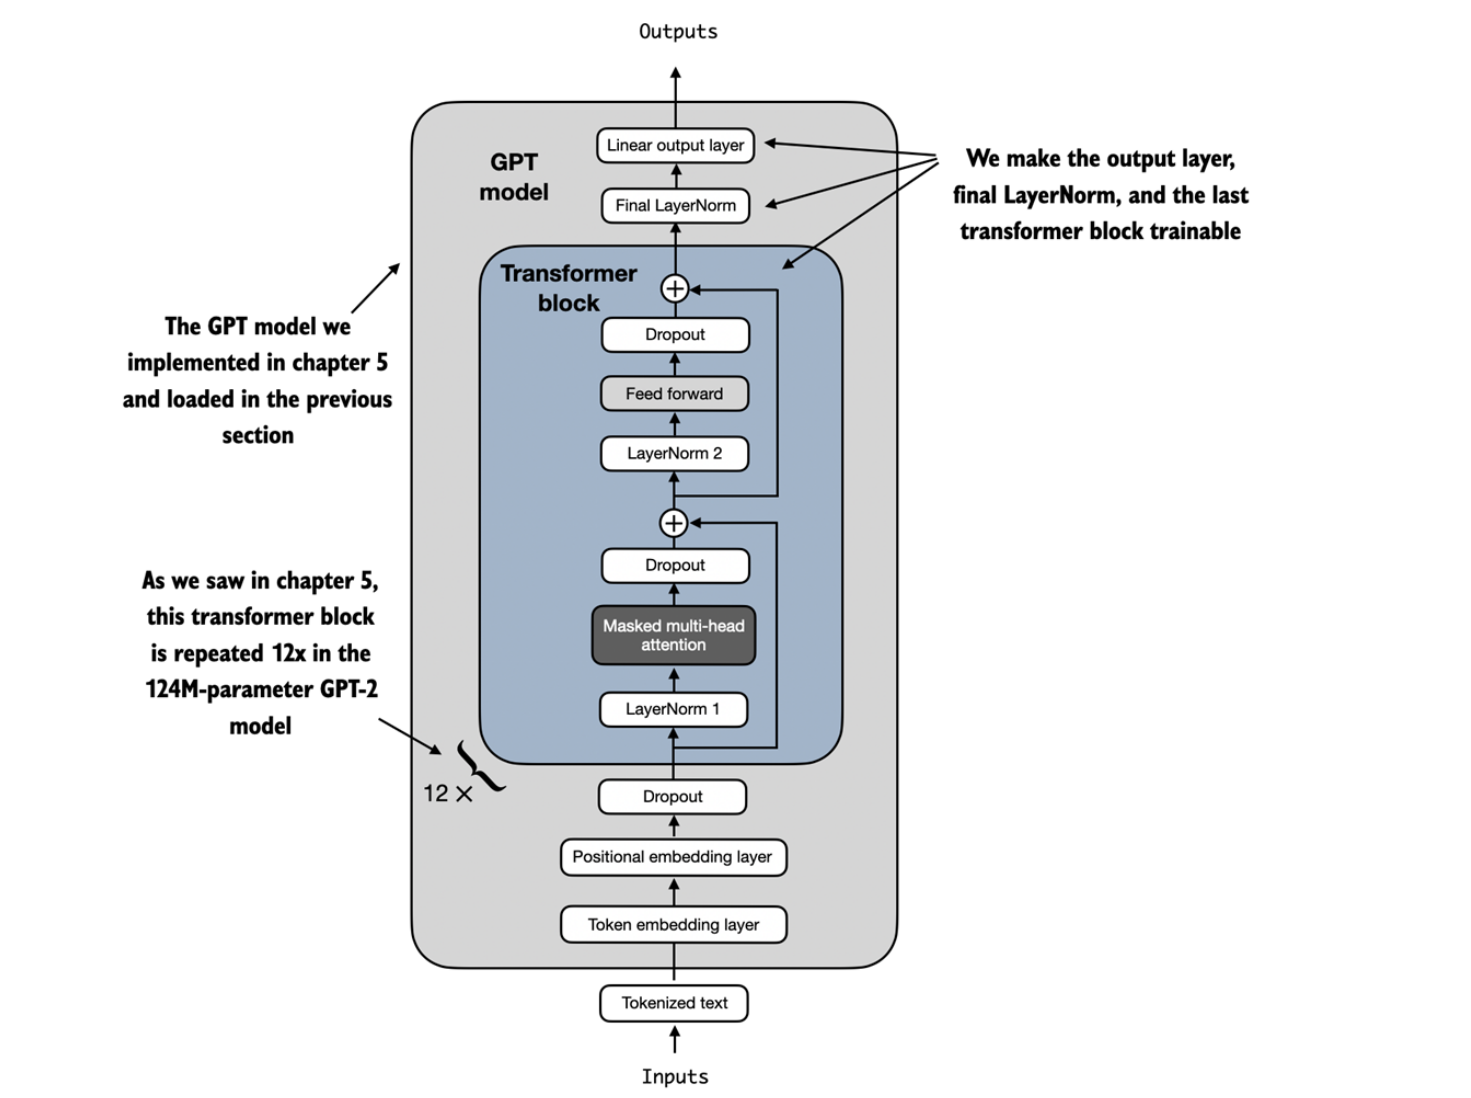

In [ ]:
if __name__ == "__main__":
    for params in model.layernorm.parameters():
            params.requires_grad = True
    for params in model.transformer[-1].parameters():
            params.requires_grad = True

### EXERCISE 6.2 FINETUNING THE WHOLE MODEL
Instead of finetuning just the final transformer block, finetune the entire model and
assess the impact on predictive performance.

I'll be back

In [ ]:
if __name__ == "__main__":
    inputs = tokenizer.encode("Do you have time")
    inputs = torch.tensor(inputs).unsqueeze(0)
    print("Inputs:", inputs)
    print("Inputs dimensions:", inputs.shape) # shape: (batch_size, num_tokens)

    with torch.no_grad():
        output = model(inputs)
    print(output)
    print(output.shape)
    # We only use the last output
    pred = output[:,-1,:]
    print("Predicted tensor: ",pred)

Inputs: tensor([[5211,  345,  423,  640]])
Inputs dimensions: torch.Size([1, 4])
tensor([[[ 1.3506, -0.7766],
         [ 0.6365, -1.1331],
         [ 0.6788, -1.1520],
         [ 0.9761, -1.0267]]])
torch.Size([1, 4, 2])
Predicted tensor:  tensor([[ 0.9761, -1.0267]])


### EXERCISE 6.3 FINETUNING THE FIRST VERSUS LAST TOKEN
Rather than finetuning the last output token, try finetuning the first output token and
observe the changes in predictive performance when finetuning the model in later
sections.

# 6.6 Calculating the classification loss and accuracy

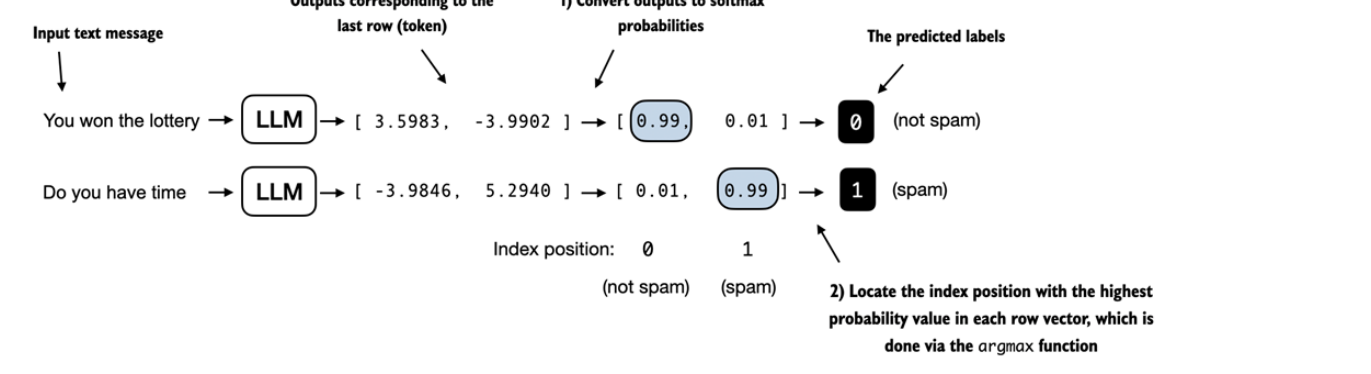

To illustrate figure 6.14 with a concrete example, let's consider the last token output from
the previous section

In [ ]:
if __name__ == "__main__":
    probas = torch.softmax(pred,dim = -1)
    label = torch.argmax(probas)
    print("Predicted label: ", label.item())

Predicted label:  0


To determine the classification accuracy, we apply the argmax-based prediction code to
all examples in the dataset and calculate the proportion of correct predictions by defining a
calc_accuracy_loader function

In [ ]:
def calc_accuracy_loader(data_loader,model,device,num_batches = None): # num_batches gioi han so batch train trong dataloader
    model.eval()
    corrected_prediction,num_examples = 0,0
    if num_batches is None:
        num_batches = len(data_loader) # Fixed: dataloader -> data_loader
    else:
        num_batches = min(num_batches, len(data_loader))

    for i,(input_batch,output_batch) in enumerate(data_loader):
        if i < num_batches:
            input_batch, output_batch = input_batch.to(device), output_batch.to(device)
            with torch.no_grad():
                output = model(input_batch)
            pred = output[:,-1,:]
            probas = torch.softmax(pred,dim = -1)
            labels = torch.argmax(probas, dim=-1) # Fixed: argmax should be over dimension -1
            num_examples += len(input_batch) # Fixed: num_example -> num_examples
            corrected_prediction += (labels == output_batch).sum().item() # Fixed: output -> output_batch
        else:
            break
    return corrected_prediction / num_examples

In [ ]:
if __name__ =="__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    torch.manual_seed(123)
    train_accuracy = calc_accuracy_loader(train_loader, model, device, num_batches=10)
    val_accuracy = calc_accuracy_loader(val_loader, model, device, num_batches=10)
    test_accuracy = calc_accuracy_loader(test_loader, model, device, num_batches=10)
    print(f"Training accuracy: {train_accuracy*100:.2f}%")
    print(f"Validation accuracy: {val_accuracy*100:.2f}%")
    print(f"Test accuracy: {test_accuracy*100:.2f}%")

Training accuracy: 42.50%
Validation accuracy: 41.25%
Test accuracy: 42.50%


In [48]:
def calc_loss_batch (input_batch,output_batch,model,device):
    input_batch = input_batch.to(device)
    output_batch = output_batch.to(device)
    # with torch.no_grad():
    pred = model(input_batch)[:,-1,:]
    probas = torch.softmax(pred,dim = -1)
    loss = nn.functional.cross_entropy(probas,output_batch)
    return loss

In [ ]:
def calc_loss_loader(data_loader,model,device,num_batches):
    loss = 0
    if(len(data_loader) == 0): return 0
    if num_batches is None:
        num_batches = len(data_loader) # Fixed: dataloader -> data_loader
    else:
        num_batches = min(num_batches, len(data_loader))
    for i,(input_batch,output_batch) in enumerate(data_loader):
        if i < num_batches:
            loss += calc_loss_batch(input_batch,output_batch,model,device)
        else:
             break
    return loss

In [ ]:
if __name__ == "__main__":
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader,model,device,num_batches= 5)
        val_loss =calc_loss_loader(val_loader,model,device,num_batches = 5)
        test_loss = calc_loss_loader(test_loader,model,device,num_batches = 5)

# 6.7 Finetuning the model on supervised data

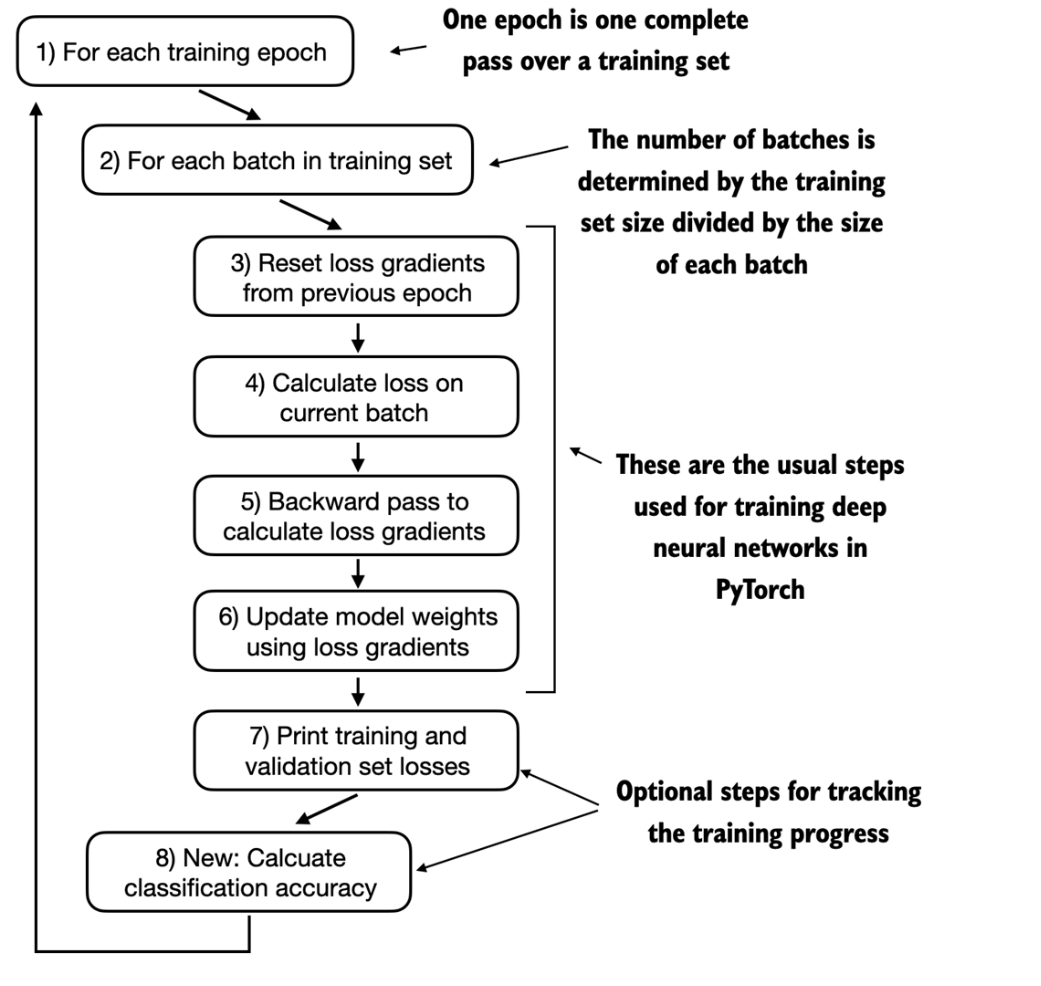

In [62]:
def train_classifier_simple(model, train_loader, val_loader, optimizer, device,num_epochs, eval_freq, eval_iter, tokenizer):
    train_losses, val_losses, train_accs, val_accs = [], [], [], []
    examples_seen, global_step = 0, -1

    for epoch in range(num_epochs):
        model.train()
        for input_batch,target_batch in train_loader:
            optimizer.zero_grad()
            loss = calc_loss_batch(input_batch,target_batch,model,device)
            loss.backward()
            optimizer.step()
            examples_seen += len(input_batch)
            global_step+= 1
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                    f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")

        train_accuracy = calc_accuracy_loader(
            train_loader, model, device, num_batches=eval_iter)
        val_accuracy = calc_accuracy_loader(
            val_loader, model, device, num_batches=eval_iter)

        print(f"Training accuracy: {train_accuracy*100:.2f}% | ", end="")
        print(f"Validation accuracy: {val_accuracy*100:.2f}%")
        train_accs.append(train_accuracy)
        val_accs.append(val_accuracy)
    return train_losses, val_losses, train_accs, val_accs, examples_seen

In [63]:
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, device,num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss

In [64]:
import time
start_time = time.time()
torch.manual_seed(123)
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.1)
num_epochs = 5
train_losses, val_losses, train_accs, val_accs, examples_seen = train_classifier_simple(
model, train_loader, val_loader, optimizer, device,
num_epochs=num_epochs, eval_freq=50, eval_iter=5,
tokenizer=tokenizer
)
end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 3.691, Val loss 3.816
Ep 1 (Step 000050): Train loss 1.861, Val loss 1.988
Ep 1 (Step 000100): Train loss 1.570, Val loss 1.577
Training accuracy: 92.50% | Validation accuracy: 95.00%
Ep 2 (Step 000150): Train loss 1.620, Val loss 1.605
Ep 2 (Step 000200): Train loss 1.691, Val loss 1.691
Ep 2 (Step 000250): Train loss 1.566, Val loss 1.692
Training accuracy: 100.00% | Validation accuracy: 97.50%
Ep 3 (Step 000300): Train loss 1.566, Val loss 1.692
Ep 3 (Step 000350): Train loss 1.566, Val loss 1.628
Training accuracy: 97.50% | Validation accuracy: 97.50%
Ep 4 (Step 000400): Train loss 1.691, Val loss 1.691
Ep 4 (Step 000450): Train loss 1.692, Val loss 1.691
Ep 4 (Step 000500): Train loss 1.566, Val loss 1.691
Training accuracy: 97.50% | Validation accuracy: 97.50%
Ep 5 (Step 000550): Train loss 1.691, Val loss 1.691
Ep 5 (Step 000600): Train loss 1.566, Val loss 1.691
Training accuracy: 100.00% | Validation accuracy: 97.50%
Training completed in 3.06 mi

In [83]:
train_losses_float = [so.item() for so in train_losses]
val_losses_float = [so.item() for so in val_losses]

In [84]:
import matplotlib.pyplot as plt
def plot_values(epochs_seen, examples_seen, train_values, val_values, label="loss"):
    fig, ax1 = plt.subplots(figsize=(5, 3))
    #A
    ax1.plot(epochs_seen, train_values, label=f"Training {label}")
    ax1.plot(epochs_seen, val_values, linestyle="-.", label=f"Validation {label}")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel(label.capitalize())
    ax1.legend()
    #B
    ax2 = ax1.twiny()
    ax2.plot(examples_seen, train_values, alpha=0)
    # Invisible plot for aligning ticks
    ax2.set_xlabel("Examples seen")
    fig.tight_layout()
    #C
    plt.savefig(f"{label}-plot.pdf")
    plt.show()

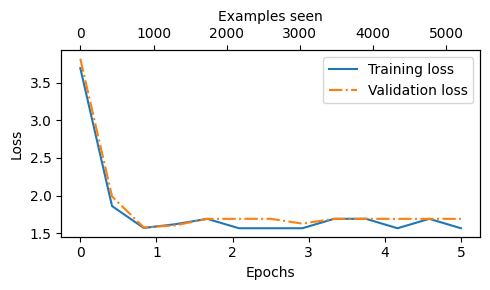

In [85]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_losses))
plot_values(epochs_tensor, examples_seen_tensor, train_losses_float, val_losses_float)

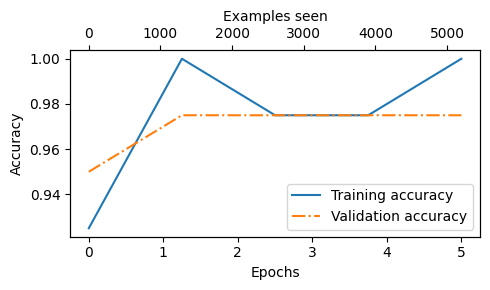

In [86]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_accs))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_accs))
plot_values(epochs_tensor, examples_seen_tensor, train_accs, val_accs, label="accuracy")

# 6.8 Using the LLM as a spam classifier

In [90]:
def classify_review(text,model,device,tokenizer,max_length = None,pad_token_id = 50256):
    model.eval()
    input = tokenizer.encode(text)
    supported_context_length = model.pos_embedded.weight.shape[1]
    input = input[:min(max_length,supported_context_length)]
    input += [pad_token_id] * (max_length - len(input))
    input_tensor = torch.tensor(input,device = device).unsqueeze(0)
    with torch.no_grad():
        logit = model(input_tensor)[:,-1,:]
    logit = torch.softmax(logit,dim = -1 )
    pred = torch.argmax(logit,dim = -1).item()
    return "spam" if pred == 1 else "not spam"

In [92]:
text_1 = (
"You are a winner you have been specially"
" selected to receive $1000 cash or a $2000 award."
)
classify_review(text,model,device,tokenizer,max_length = train_dataset.max_length)

'spam'

In [95]:
text_2 = (
"Hey, just wanted to check if we're still on"
" for dinner tonight? Let me know!"
)
classify_review(
text_2, model, device,tokenizer, max_length=train_dataset.max_length
)

'not spam'

# Save model

In [96]:
torch.save(model.state_dict(), "review_classifier.pth")

In [97]:
model_state_dict = torch.load("review_classifier.pth")
model.load_state_dict(model_state_dict)

<All keys matched successfully>